In [22]:
# Pandas Library is imported or declared for data analysis
import pandas as pd

In [23]:
dataset=pd.read_csv("Salary_Data.csv") #using the pandas library read the csv file and assigned to dataset variable

In [24]:
dataset # display the dataset variable

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [25]:
independent=dataset[["YearsExperience"]] # get the years of experience column data and assign it to independent variable
independent # display the independent variable

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [26]:
dependent=dataset[["Salary"]] # get the Salary column data and assign it to dependent variable
dependent  # display the dependent variable

,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0
5,56642.0
6,60150.0
7,54445.0
8,64445.0
9,57189.0


In [27]:
pip install python.exe --upgrade pip 

Note: you may need to restart the kernel to use updated packages.


### install sci-learn to use the sklearn library

In [28]:

pip install scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.model_selection import train_test_split # import the train-test_split function from model_selection module of sklearn library
X_train,X_test,y_train,y_test=train_test_split(independent, dependent, test_size=0.30,random_state=0) # split the data set for training and testing the model


In [48]:
from sklearn.linear_model import LinearRegression # import the LinearRegression class from linear_model of sklearn library
regressor=LinearRegression() #Create an object of the LinearRegressio class and assign it  regressor 
regressor.fit(X_train,y_train) # Create the model using the training set of dependant and independant variables

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[9360.26]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[26777.39]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


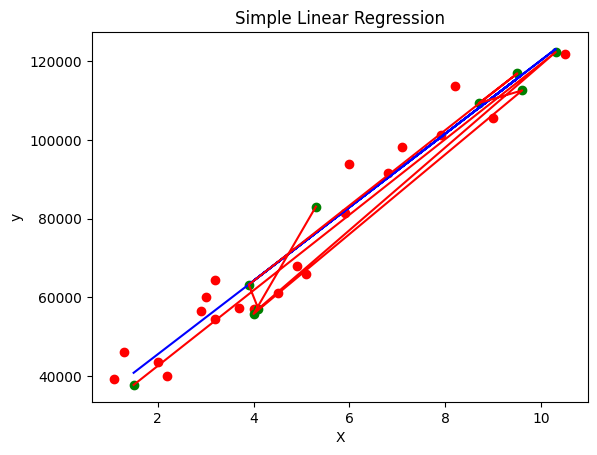

In [49]:

import matplotlib.pyplot as plt

# Scatter plot of training data
plt.scatter(X_train, y_train, color='red')
# Scatter plot of test data
plt.scatter(X_test, y_test, color='green')
# Regression line of testing data prediction
plt.plot(X_test, regressor.predict(X_test), color='blue')

plt.plot(X_test, y_test, color='red')

plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()




In [50]:
#Get the weight once model is created, during model creation the weight and bias values are calculated and set 
#in the coed_and intercept accordingly
weight=regressor.coef_ 
weight # Display the weight/slop

array([[9360.26128619]])

In [51]:
bais=regressor.intercept_
bais # Display the bias

array([26777.3913412])

In [52]:
# Once the model is created the prediction can be done for the test set.
y_pred=regressor.predict(X_test)
y_pred

array([[ 40817.78327049],
       [123188.08258899],
       [ 65154.46261459],
       [ 63282.41035735],
       [115699.87356004],
       [108211.66453108],
       [116635.89968866],
       [ 64218.43648597],
       [ 76386.77615802]])

In [55]:
from sklearn.metrics import r2_score #R square score is calculated by importing the metrics module. 
r_score=r2_score(y_test,y_pred)

In [56]:
r_score # diplaying the score. Since it is near to 1 the score is good and our model is trained well

0.9740993407213511

In [57]:
import pickle #Deployment using Pickle
filename="finalized_model_linear.sav" # assign the filename vaiable

In [58]:
pickle.dump(regressor,open(filename,'wb'))  # Saves the trained model to disk and can be reused

In [59]:
loaded_model=pickle.load(open("finalized_model_linear.sav",'rb')) # Load the saved model
result=loaded_model.predict([[13]]) # Now we can start predicting

C:\Users\prabha_7589\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [60]:
result #Display the result variable

array([[148460.78806172]])